In [5]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# Path to data

In [6]:
data_path = "/dvs_ro/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.5"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
meta  = LegendMetadata(config["metadata"])
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r000.phy.start_key)

# Get files

In [7]:
detector = "V02160A"

chn = chmap.V02160A.daq.rawid  # seleziono un detector
channel = f'ch{chn}'

In [8]:
pet_files = sorted(glob.glob(f"{config['tier_pet']}/phy/l200-p0[346789]-*-phy-tier_pet.lh5"))

In [249]:
# sempre sorted list
psp_files = sorted(glob.glob(f"{config["tier_psp"]}/cal/p03/r000/*.lh5")) #access exsiting DSP-processed data such as the energy
tcm_files = sorted(glob.glob(f"{config["tier_tcm"]}/cal/p03/r000/*.lh5"))
raw_files = sorted(glob.glob(f"{config["tier_raw"]}/cal/p03/r000/*.lh5"))
cal_file = f"{config["par_pht"]}/cal/p03/r000/l200-p03-r000-cal-20230311T235840Z-par_pht.json"

# PSP files

In [256]:
params = [
        "bl_slope",
        "cuspEmax_cal",
    "cuspEmax_ctc_cal"
    ]


In [257]:
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]

In [258]:
data, threshold_mask = load_data(
    files = psp_files,
    lh5_path = f"{channel}/dsp",
    cal_dict = cal_dict,
    params=params,
    threshold=500,
    return_selection_mask=True,
)

In [259]:
data

,bl_slope,cuspEmax,cuspEmax_cal,cuspEmax_ctc,cuspEmax_ctc_cal
1,-0.006739,13983.070312,2163.329842,13990.515258,2163.329842
4,0.035644,10833.942383,1676.312842,10840.505236,1676.312842
5,-0.723120,3710.949707,573.787966,3712.261935,573.787966
6,0.040089,5320.745117,822.866581,5322.304410,822.866581
12,0.017360,3617.411621,559.292575,3618.570035,559.292575
...,...,...,...,...,...
277507,-0.028505,14407.253906,2228.536812,14412.330444,2228.536812
277508,-0.016287,16911.367188,2615.229683,16914.079729,2615.229683
277513,-0.002840,16908.015625,2614.944211,16912.232660,2614.944211
277516,-0.020165,7316.215820,1131.367017,7316.728757,1131.367017


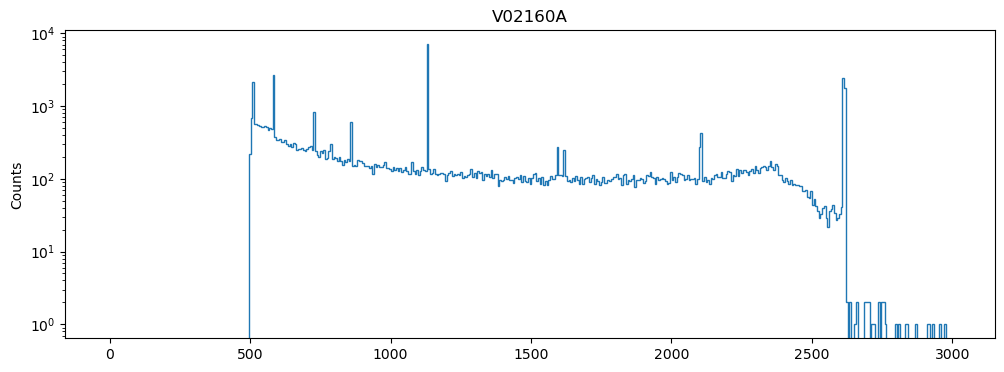

In [260]:
plt.figure(figsize = (12,4))
plt.hist(data.cuspEmax_cal, bins = 500, range = (-10, 3000), histtype = 'step')
plt.ylabel(f"Counts")
plt.title(f"{detector}")
plt.yscale('log')
